# GHaLIB غالب: Generating Hope and Linguistic Irony in Banter

### **Setting Modules**

In [2]:
%%capture
!pip install transformers datasets accelerate -q
!pip install evaluate

In [5]:
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification
import seaborn as sns
import warnings
import torch
from transformers import Trainer
from transformers import TrainingArguments
import numpy as np
import evaluate

warnings.filterwarnings('ignore')

### **Loading**

In [6]:
en_train  = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/Training_Data_PolyHope-M_2025/Training Data/en_train.csv')
en_dev = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/Training_Data_PolyHope-M_2025/Training Data/en_dev.csv')
en_test = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/TestWithNoLabel/TestWithNoLabel/en_test_without_labels.csv')
en_train.head()

,text,binary,multiclass
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope


In [7]:
en_train['multiclass'].unique()

array(['Not Hope', 'Generalized Hope', 'Realistic Hope',
       'Unrealistic Hope'], dtype=object)

### **Text Preprocessing**

In [8]:
label_mapping = {'Not Hope':0, 'Generalized Hope':1, 'Realistic Hope':2, 'Unrealistic Hope':3}

en_train['multiclass'] = en_train['multiclass'].map(label_mapping)
en_dev['multiclass'] = en_dev['multiclass'].map(label_mapping)

en_train.drop(columns=['binary'], inplace=True)
en_dev.drop(columns=['binary'], inplace=True)

en_train.dropna(inplace=True)
en_dev.dropna(inplace=True)

### **Token Distributions**

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

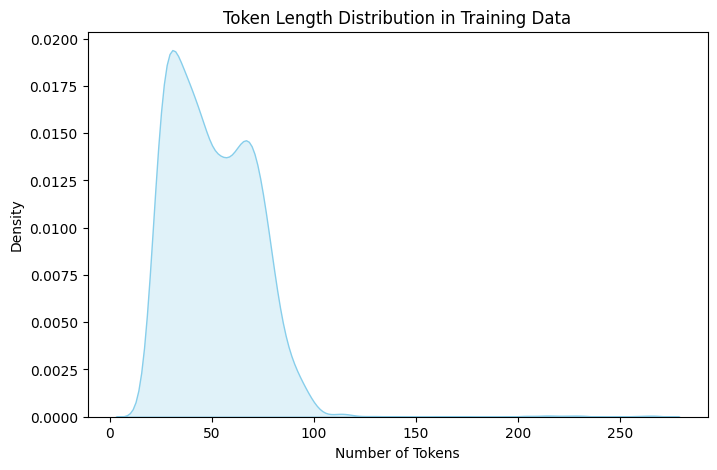

In [9]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

train_text_lengths = [len(tokenizer.tokenize(text)) for text in en_train['text']]

plt.figure(figsize=(8,5))
sns.kdeplot(train_text_lengths, fill=True, color='skyblue')
plt.xlabel("Number of Tokens")
plt.ylabel("Density")
plt.title("Token Length Distribution in Training Data")
plt.show()

In [10]:
Max_length = int(np.percentile(train_text_lengths, 97))
Max_length

87

## **RoBERTa Finetuning Pipeline**

### **Tokenization with XLM-RoBERTa**

In [11]:
def tokenize_data(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=Max_length)

train_texts = en_train["text"].tolist()
train_labels = en_train["multiclass"].tolist()

dev_texts = en_dev["text"].tolist()
dev_labels = en_dev["multiclass"].tolist()

train_encodings = tokenizer(train_texts, padding=True, truncation=True, max_length=256)
dev_encodings = tokenizer(dev_texts, padding=True, truncation=True, max_length=256)

### **Dataset Loader for Hope Data**

In [12]:
class HopeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

In [13]:
train_dataset = HopeDataset(train_encodings, train_labels)
dev_dataset = HopeDataset(dev_encodings, dev_labels)

### **Define Metrics for Evaluation**

In [14]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_score = f1.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}


### **Initialize Trainer and Fine-Tune the Model**

In [16]:
len(en_train['multiclass'].unique())

4

In [30]:
model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=4)

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",  # Set F1-score as the best model metric
    greater_is_better=True,  # Ensures higher F1 is considered better
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.942900,0.804452,0.704848,0.548234
2,0.650100,0.689779,0.740000,0.665333
3,0.470800,0.704884,0.756364,0.700952
4,0.295100,0.798948,0.751515,0.689782
5,0.220100,0.961369,0.754545,0.701479


TrainOutput(global_step=1420, training_loss=0.5639508015672926, metrics={'train_runtime': 712.8276, 'train_samples_per_second': 31.852, 'train_steps_per_second': 1.992, 'total_flos': 2987021893539840.0, 'train_loss': 0.5639508015672926, 'epoch': 5.0})

### Evaluate the Model

In [31]:
trainer.evaluate()

{'eval_loss': 0.9613686800003052,
 'eval_accuracy': 0.7545454545454545,
 'eval_f1': 0.7014788850122047,
 'eval_runtime': 11.7605,
 'eval_samples_per_second': 140.3,
 'eval_steps_per_second': 8.843,
 'epoch': 5.0}

### **Save the Model**

In [32]:
output_dir = "/kaggle/working/xlm-roberta-hope"

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('/kaggle/working/xlm-roberta-hope/tokenizer_config.json',
 '/kaggle/working/xlm-roberta-hope/special_tokens_map.json',
 '/kaggle/working/xlm-roberta-hope/sentencepiece.bpe.model',
 '/kaggle/working/xlm-roberta-hope/added_tokens.json',
 '/kaggle/working/xlm-roberta-hope/tokenizer.json')

### **Loading the Model for Inference**

In [33]:
model_path = "/kaggle/working/xlm-roberta-hope"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

device = torch.device("cpu")
model.to(device)

if "en_test" not in globals():
    raise ValueError("❌ 'en_test' DataFrame is not defined.")

test_texts = en_test["text"].tolist()

max_length = Max_length
encoded_inputs = tokenizer(
    test_texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt"
)

encoded_inputs = {key: val.to(device) for key, val in encoded_inputs.items()}

print('Processing...')
with torch.no_grad():
    outputs = model(**encoded_inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1).numpy()

Processing...


In [34]:
label_map = {0:'Not Hope', 1:'Generalized Hope', 2:'Realistic Hope', 3:'Unrealistic Hope'}

predicted_labels = [label_map[pred] for pred in predictions]

submission_df = pd.DataFrame({"Text": test_texts, "Tag": predicted_labels})
submission_df.to_csv("predictions.csv", index=False)

print("✅ Predictions successfully saved to 'predictions.csv' using CPU.")

✅ Predictions successfully saved to 'predictions.csv' using CPU.


### **Inference**

In [35]:
pd.read_csv('/kaggle/working/predictions.csv').head()

,Text,Tag
0,#USER# #USER# #USER# Booked at Northampton on ...,Not Hope
1,There're 2 types of lawmakers. And you only fi...,Realistic Hope
2,#USER# #USER# #USER# #USER# What if The parent...,Not Hope
3,#USER# #USER# #USER# #USER# #USER# #USER# #USE...,Realistic Hope
4,#USER# #USER# If you don’t believe in abortion...,Not Hope
